In [ ]:
!pip install scikit-learn numpy pandas matplotlib

zsh:1: /Users/sebastiaokomada/Documents/Curso-IA/venv/bin/pip: bad interpreter: /Users/sebastiaokomada/Desktop/Curso-IA/venv/bin/python3.11: no such file or directory
  Using cached scikit_learn-1.9.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-macosx_12_0_arm64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='str')


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


Acurácia no treino: 0.9781659388646288
Acurácia no teste: 0.7557251908396947
Cross-validation scores: [0.76335878 0.79007634 0.77862595 0.7480916  0.77394636]
Média da acurácia: 0.7708198063817965
Desvio padrão da acurácia: 0.014239124777620914
Melhor score na validação cruzada: 0.8099964362081253
Melhores hiperparâmetros:
{'classifier__bootstrap': True, 'classifier__max_depth': 3, 'classifier__max_features': None, 'classifier__min_samples_leaf': 7, 'classifier__min_samples_split': 13, 'classifier__n_estimators': 363}
[0 1]

===== AVALIAÇÃO NO CONJUNTO DE TESTE =====

Acurácia no teste com melhor modelo:
0.7684478371501272

Relatório de classificação:
                precision    recall  f1-score   support

Não sobreviveu       0.81      0.89      0.85       290
    Sobreviveu       0.58      0.42      0.49       103

      accuracy                           0.77       393
     macro avg       0.70      0.66      0.67       393
  weighted avg       0.75      0.77      0.75       393




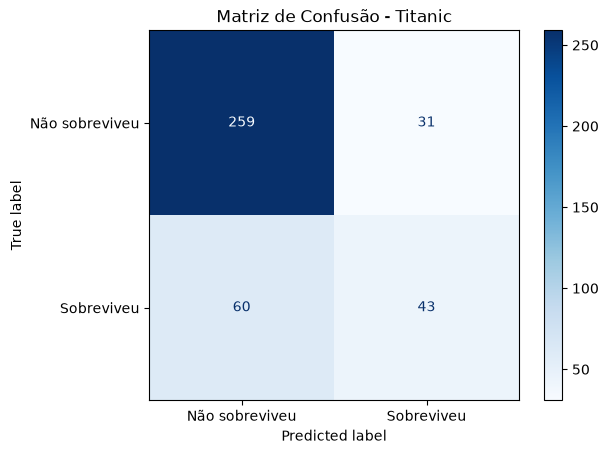

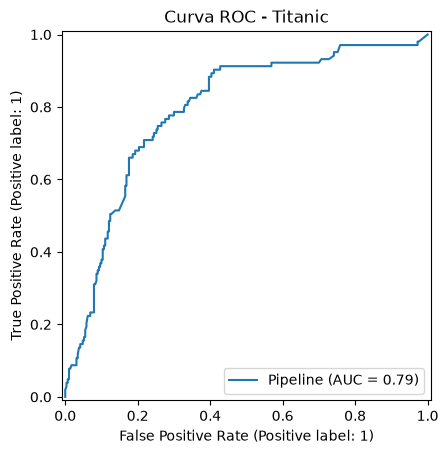

In [35]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)
from scipy.stats import randint

df = pd.read_csv('dataset_titanic.csv')

print(df.columns)
display(df.head())
#print(df.dtypes)
#print(df.isna().sum())

# Entrada e saída
X_titanic = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]
y_titanic = df['2urvived']

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.3,
    random_state=42,
    stratify=y_titanic
)

# Features numéricas e categóricas
features_numericas = ['Pclass', 'Age', 'Fare']
features_categoricas = ['Sex', 'Embarked']


# Transformador numérico
transformador_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

# Transformador categórico
transformador_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', transformador_numerico, features_numericas),
    ('cat', transformador_categorico, features_categoricas)
])

# Pipeline final
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Treinando
pipe.fit(X_train, y_train)

# Avaliação
y_pred = pipe.predict(X_test)

print(f'Acurácia no treino: {pipe.score(X_train, y_train)}')
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred)}')

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_distributions = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": [None, 3, 5, 8, 10, 15],
    "classifier__min_samples_split": randint(2, 20),
    "classifier__min_samples_leaf": randint(1, 10),
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__bootstrap": [True, False]
}

scores = cross_val_score(
    pipe,
    X_titanic,
    y_titanic,
    cv=cv,
    scoring='accuracy'
)

print(f'Cross-validation scores: {scores}')
print(f'Média da acurácia: {scores.mean()}')
print(f'Desvio padrão da acurácia: {scores.std()}')

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Melhor score na validação cruzada:", random_search.best_score_)
print("Melhores hiperparâmetros:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

# Classe 1 = sobreviveu
# Classe 0 = não sobreviveu 

print(best_model.classes_)


y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n===== AVALIAÇÃO NO CONJUNTO DE TESTE =====")
print("\nAcurácia no teste com melhor modelo:")
print(accuracy_score(y_test, y_pred_best))
print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Não sobreviveu", "Sobreviveu"]

))
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_best))
print("\nROC AUC:")
print(roc_auc_score(y_test, y_proba_best))


ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Não sobreviveu", "Sobreviveu"],
    cmap="Blues"
)

plt.title("Matriz de Confusão - Titanic")
plt.show()

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)
plt.title("Curva ROC - Titanic")
plt.show()